# Air Hockey Policy Research Notebook

Deze notebook analyseert SAC- en PPO-trainingruns, TensorBoard-logboeken en modelprestaties. De standaardweergave benchmarkt de drie curriculumstages en de finale PPO-policy tegen dezelfde complexe tegenstander.

Doel:
- PPO-traininglogs visualiseren wanneer TensorBoard-events aanwezig zijn
- de drie curriculum-checkpoints vergelijken op dezelfde seeded episodes
- goals, win rate, schoten, reactiesnelheid en mallet-snelheid beoordelen
- robotposities plotten om middenlijn- en randcamping te signaleren

De notebook zoekt de project-root automatisch en werkt met checkpoints onder `models/Sessie04`.

In [13]:
from pathlib import Path
import importlib
import sys

PROJECT_ROOT = next(
    (
        parent
        for parent in (Path.cwd(), *Path.cwd().parents)
        if (parent / "ai" / "air_hockey_env.py").is_file()
    ),
    Path(__file__).resolve().parents[1] if "__file__" in globals() else None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root containing ai/air_hockey_env.py")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from ai.air_hockey_env import AirHockeyGymEnv
import research.analytics as analytics
analytics = importlib.reload(analytics)
from research.analytics import (
    MODEL_ROOT,
    PROJECT_ROOT,
    TB_LOG_ROOT,
    collect_robot_positions,
    evaluate_model,
    find_tensorboard_runs,
    heatmap_robot_positions,
    load_tensorboard_metrics,
    plot_tensorboard_metrics,
)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")
pd.set_option("display.max_columns", 30)

MODEL_ROOT = PROJECT_ROOT / "models" / "Sessie04"
EVAL_EPISODES = 20
EVAL_SEED = 11
MAX_EPISODE_STEPS = 1000
DEFAULT_ALGORITHM = "ppo"
DEFAULT_REWARD_MODE = "defensive"
EVAL_OPPONENT = "complex"
DEFAULT_MODEL = MODEL_ROOT / "final_curriculum_ppo.zip"
CURRICULUM_MODELS = [
    ("Stage 1: No Opponent", MODEL_ROOT / "final_curriculum_ppo_stage1.zip", "aggressive"),
    ("Stage 2: Static Opponent", MODEL_ROOT / "final_curriculum_ppo_stage2.zip", "defensive"),
    ("Stage 3: Complex Opponent", MODEL_ROOT / "final_curriculum_ppo.zip", "defensive"),
]

print(f"Project root: {PROJECT_ROOT}")
print(f"Evaluation: {DEFAULT_ALGORITHM.upper()} vs {EVAL_OPPONENT} opponent")
print(f"TensorBoard run directories: {len(find_tensorboard_runs(TB_LOG_ROOT))}")
print(f"Final model exists: {DEFAULT_MODEL.is_file()} ({DEFAULT_MODEL})")
for stage_name, model_path, _reward_mode in CURRICULUM_MODELS:
    print(f"{stage_name}: {model_path.is_file()} ({model_path})")

Project root: c:\Users\timoz\Documents\00.school\jaar 4\New folder\NHLstenden-Air-Hockey-Ai\Orion Vision
Evaluation: PPO vs complex opponent
TensorBoard run directories: 0
Final model exists: True (c:\Users\timoz\Documents\00.school\jaar 4\New folder\NHLstenden-Air-Hockey-Ai\Orion Vision\models\Sessie04\final_curriculum_ppo.zip)
Stage 1: No Opponent: True (c:\Users\timoz\Documents\00.school\jaar 4\New folder\NHLstenden-Air-Hockey-Ai\Orion Vision\models\Sessie04\final_curriculum_ppo_stage1.zip)
Stage 2: Static Opponent: True (c:\Users\timoz\Documents\00.school\jaar 4\New folder\NHLstenden-Air-Hockey-Ai\Orion Vision\models\Sessie04\final_curriculum_ppo_stage2.zip)
Stage 3: Complex Opponent: True (c:\Users\timoz\Documents\00.school\jaar 4\New folder\NHLstenden-Air-Hockey-Ai\Orion Vision\models\Sessie04\final_curriculum_ppo.zip)


In [14]:
# 1. TensorBoard PPO scalars and reward trends

metrics = load_tensorboard_metrics(TB_LOG_ROOT)
available_tags = sorted(metrics)
print(f"Loaded {len(available_tags)} scalar tags from {TB_LOG_ROOT}")
print("Tags:", available_tags if available_tags else "No event files found")

reward_tag = next(
    (tag for tag in ("rollout/ep_rew_mean", "ep_rew_mean") if tag in metrics),
    None,
)
key_tags = [
    reward_tag,
    "train/value_loss",
    "train/policy_gradient_loss",
    "train/entropy_loss",
    "train/approx_kl",
    "train/ent_coef",
]
selected_tags = [tag for tag in key_tags if tag is not None and tag in metrics]

if selected_tags:
    figures = plot_tensorboard_metrics(metrics, selected_tags=selected_tags)
    plt.show()
else:
    print("No PPO scalar logs found. Train from the dashboard or point TB_LOG_ROOT at the PPO event folder.")

Loaded 0 scalar tags from c:\Users\timoz\Documents\00.school\jaar 4\New folder\NHLstenden-Air-Hockey-Ai\Orion Vision\sac_air_hockey_tensorboard
Tags: No event files found
No PPO scalar logs found. Train from the dashboard or point TB_LOG_ROOT at the PPO event folder.


In [19]:
# 2. PPO reward trend and optimization signals

if reward_tag is not None:
    reward_frame = metrics[reward_tag].copy().sort_values(["run", "step"])
    reward_frame["rolling_reward"] = reward_frame.groupby("run")["value"].transform(
        lambda values: values.rolling(
            window=max(3, min(25, len(values) // 5 or 3)),
            min_periods=1,
        ).mean()
    )
    fig, ax = plt.subplots(figsize=(11, 5))
    sns.lineplot(
        data=reward_frame,
        x="step",
        y="value",
        hue="run",
        alpha=0.25,
        legend=False,
        ax=ax,
    )
    sns.lineplot(data=reward_frame, x="step", y="rolling_reward", hue="run", ax=ax)
    ax.set(
        title="PPO episode reward: raw values and rolling mean",
        xlabel="Training steps",
        ylabel="Mean episode reward",
    )
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    plt.show()
else:
    print("No PPO episode-reward series is available for trend analysis.")

for tag in ["train/value_loss", "train/policy_gradient_loss", "train/entropy_loss", "train/approx_kl"]:
    if tag in metrics:
        frame = metrics[tag]
        print(
            f"{tag}: {len(frame):,} samples; {frame['run'].nunique()} run(s); "
            f"step range {frame['step'].min():,}-{frame['step'].max():,}"
        )

print("Use held-out episodes against the same opponent to compare policies; training reward alone is not a performance measure.")

No PPO episode-reward series is available for trend analysis.
Use held-out episodes against the same opponent to compare policies; training reward alone is not a performance measure.


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


,value
episodes,20.000000
goals_for,1.000000
goals_against,9.000000
wins,1.000000
draws,10.000000
win_rate,5.000000
goal_ratio,10.000000
goals_against_ratio,90.000000
avg_episode_length,728.650000
avg_episode_duration_s,6.072083


,episode,goals_for,goals_against,won,draw,episode_length,episode_duration_s,episode_return,shots,shots_per_minute,avg_mallet_speed,reaction_time_s
0,1,0,1,False,False,125,1.041667,-21.197440,0,0.000000,1.810452,NaN
1,2,0,1,False,False,292,2.433333,12.717389,1,24.657534,1.630718,0.000000
2,3,0,0,False,True,1000,8.333333,119.690242,3,21.600000,1.937225,0.433333
3,4,0,0,False,True,1000,8.333333,281.476152,6,43.200000,1.864768,0.350000
4,5,1,0,True,False,879,7.325000,187.575411,14,114.675768,2.089178,0.100000
5,6,0,1,False,False,796,6.633333,184.729398,9,81.407035,1.977526,0.366667
6,7,0,0,False,True,1000,8.333333,311.355080,34,244.800000,2.068772,0.475000
7,8,0,1,False,False,105,0.875000,-21.740012,0,0.000000,1.830954,0.391667
8,9,0,0,False,True,1000,8.333333,205.607752,4,28.800000,1.892153,0.391667
9,10,0,1,False,False,777,6.475000,149.478016,19,176.061776,1.918860,0.000000


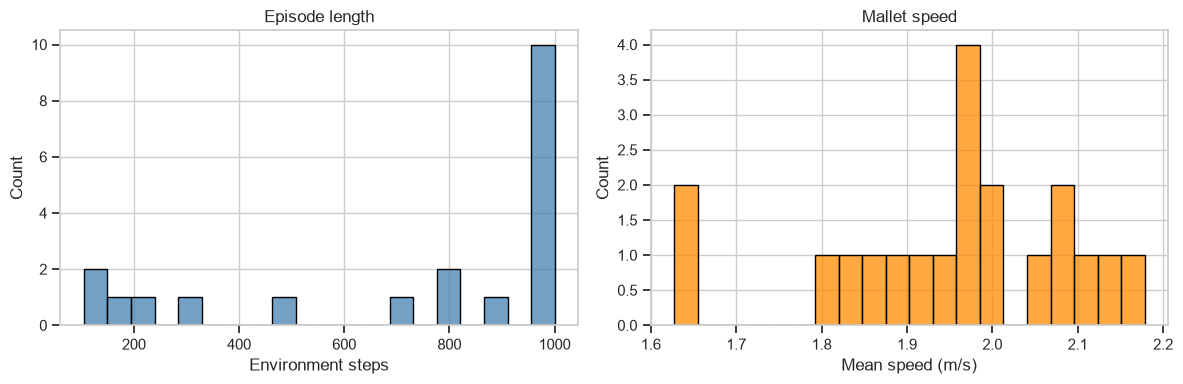

In [16]:
# 3. Deterministic benchmark of the final PPO curriculum policy

if DEFAULT_MODEL.is_file():
    eval_df, summary = evaluate_model(
        model_path=DEFAULT_MODEL,
        episodes=EVAL_EPISODES,
        reward_mode=DEFAULT_REWARD_MODE,
        max_steps=MAX_EPISODE_STEPS,
        seed=EVAL_SEED,
        algorithm=DEFAULT_ALGORITHM,
        opponent_type=EVAL_OPPONENT,
    )
    summary_df = pd.Series(summary, name="value").to_frame()
    display(summary_df)
    display(eval_df.head(10))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(data=eval_df, x="episode_length", bins=20, ax=axes[0], color="steelblue")
    axes[0].set(title="Episode length", xlabel="Environment steps")
    sns.histplot(data=eval_df, x="avg_mallet_speed", bins=20, ax=axes[1], color="darkorange")
    axes[1].set(title="Mallet speed", xlabel="Mean speed (m/s)")
    fig.tight_layout()
    plt.show()
else:
    eval_df = pd.DataFrame()
    summary = {}
    print(f"No trained model found at {DEFAULT_MODEL}; PPO benchmark is skipped.")

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


,win_rate,goals_for,goals_against,goal_ratio,avg_episode_return,avg_shots_per_minute,avg_mallet_speed,avg_reaction_time_s
stage,,,,,,,,
Stage 1: No Opponent,10.0,2,9,18.181818,369.203985,31.094926,2.058950,0.789216
Stage 2: Static Opponent,10.0,2,8,20.000000,82.273655,70.706005,1.807415,0.329583
Stage 3: Complex Opponent,5.0,1,9,10.000000,128.616958,79.960106,1.952428,0.241667


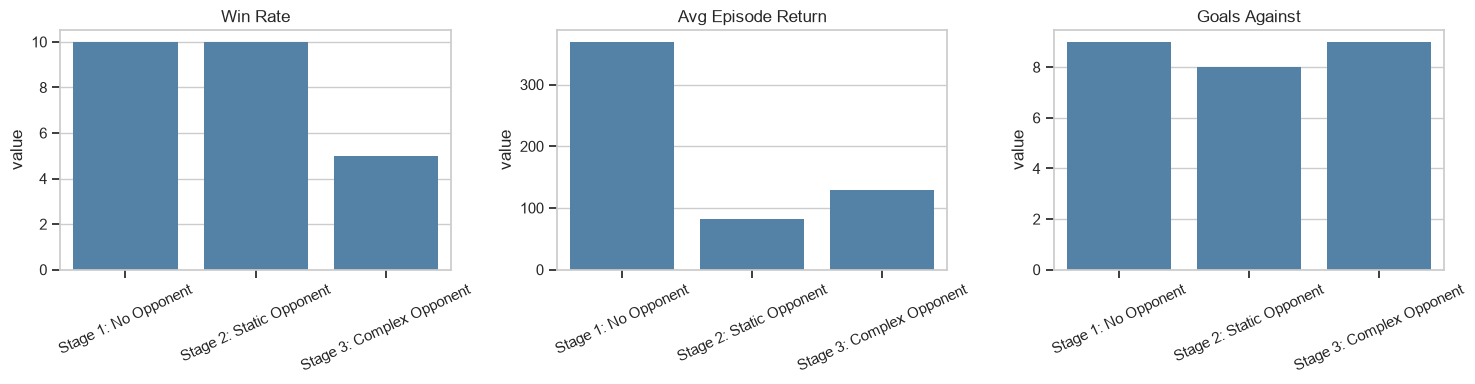

In [17]:
# 4. Compare PPO curriculum stages against the same complex opponent

stage_rows = []
missing_stage_models = []
for stage_name, model_path, reward_mode in CURRICULUM_MODELS:
    if not model_path.is_file():
        missing_stage_models.append(str(model_path))
        continue
    _, stage_summary = evaluate_model(
        model_path=model_path,
        episodes=EVAL_EPISODES,
        reward_mode=reward_mode,
        max_steps=MAX_EPISODE_STEPS,
        seed=EVAL_SEED,
        algorithm="ppo",
        opponent_type=EVAL_OPPONENT,
    )
    stage_summary["stage"] = stage_name
    stage_rows.append(stage_summary)

curriculum_df = pd.DataFrame(stage_rows)
if missing_stage_models:
    print("Missing curriculum archives:", missing_stage_models)

if not curriculum_df.empty:
    comparison_columns = [
        "stage",
        "win_rate",
        "goals_for",
        "goals_against",
        "goal_ratio",
        "avg_episode_return",
        "avg_shots_per_minute",
        "avg_mallet_speed",
        "avg_reaction_time_s",
    ]
    display(curriculum_df[comparison_columns].set_index("stage"))

    plot_frame = curriculum_df.melt(
        id_vars="stage",
        value_vars=["win_rate", "avg_episode_return", "goals_against"],
        var_name="metric",
        value_name="value",
    )
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for axis, metric in zip(axes, ["win_rate", "avg_episode_return", "goals_against"]):
        sns.barplot(
            data=plot_frame[plot_frame["metric"] == metric],
            x="stage",
            y="value",
            ax=axis,
            color="steelblue",
        )
        axis.set_title(metric.replace("_", " ").title())
        axis.set_xlabel("")
        axis.tick_params(axis="x", rotation=25)
    fig.tight_layout()
    plt.show()
else:
    print("No PPO curriculum checkpoints found to compare.")

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Collected 14,573 robot positions


,x_m,y_m
count,14573.000000,14573.000000
mean,-0.356766,-0.015054
std,0.295214,0.233581
min,-0.927000,-0.442000
25%,-0.559946,-0.202159
50%,-0.150000,-0.030089
75%,-0.150000,0.164227
max,-0.150000,0.442000


Within 5 cm of forward limit (x >= -0.20 m): 59.1%
Back third of own half (x < -0.65 m): 22.1%
Near side walls (|y| > 0.35 m): 15.9%


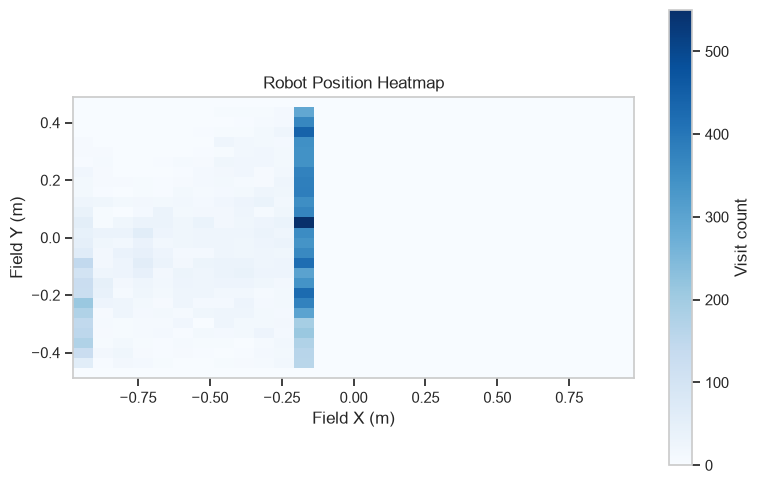

In [21]:
# 5. Final PPO robot-position heatmap

if DEFAULT_MODEL.is_file():
    robot_positions = collect_robot_positions(
        model_path=DEFAULT_MODEL,
        episodes=EVAL_EPISODES,
        reward_mode=DEFAULT_REWARD_MODE,
        max_steps=MAX_EPISODE_STEPS,
        seed=EVAL_SEED,
        algorithm=DEFAULT_ALGORITHM,
        opponent_type=EVAL_OPPONENT,
    )
    positions_array = np.asarray(robot_positions)
    print(f"Collected {len(positions_array):,} robot positions")
    display(pd.DataFrame(positions_array, columns=["x_m", "y_m"]).describe())
    print(f"Within 5 cm of forward limit (x >= -0.20 m): {100 * np.mean(positions_array[:, 0] >= -0.20):.1f}%")
    print(f"Back third of own half (x < -0.65 m): {100 * np.mean(positions_array[:, 0] < -0.65):.1f}%")
    print(f"Near side walls (|y| > 0.35 m): {100 * np.mean(np.abs(positions_array[:, 1]) > 0.35):.1f}%")
    heatmap_robot_positions([positions_array])
    plt.show()
else:
    print("Position heatmap skipped because the final PPO archive is unavailable.")

## Interpretatie en methodologie

- De standaardbenchmark laadt `models/Sessie04/final_curriculum_ppo.zip` als PPO en test tegen de `complex` opponent. Pas `DEFAULT_MODEL`, `MODEL_ROOT` of `EVAL_OPPONENT` aan wanneer je een ander opgeslagen model of een andere match-up wilt bekijken.
- De stagevergelijking gebruikt dezelfde seed-reeks en dezelfde complex opponent voor Stage 1, 2 en 3. Zo meet je of latere training de policy verbetert onder een gemeenschappelijke testconditie.
- TensorBoard toont PPO-specifieke rollout reward-, value-loss-, policy-gradient-, entropy- en KL-tags wanneer eventbestanden aanwezig zijn. Geen eventbestanden betekent dat de modelbenchmark nog steeds werkt, maar dat er geen trainingscurve beschikbaar is.
- `win_rate` is het aandeel episodes waarin de robot meer goals scoort dan de opponent. `goal_ratio` en `goals_against_ratio` verdelen alle goals voor/tegen.
- Schoten tellen robot-malletcontacten waarna de puck richting het doel van de tegenstander beweegt. Schotfrequentie is genormaliseerd per speelminuut.
- Reactietijd meet de tijd vanaf een puck die de robothelft in beweegt tot de mallet aantoonbaar richting puck beweegt. Episodes zonder zo'n reactie tellen niet mee in het gemiddelde (`NaN`).
- De heatmap toont robotposities in meters; langdurige concentratie langs de middellijn of een rand kan positionele camping zichtbaar maken.

De helpers in `research/analytics.py` ondersteunen zowel SAC als PPO. Voor een nieuwe custom PPO-opslag kun je de paden in `CURRICULUM_MODELS` aanpassen.